# Wind Power Forecast Error Analysis Report

### Executive Summary
This report provides a detailed analysis of wind power generation forecasts in the United Kingdom for January 2024. The objective is to evaluate forecast accuracy, identify temporal error patterns, and estimate the reliable contribution of wind power to the national grid.

**Key Objectives:**
1. Quantify forecast accuracy using standardized metrics (MAE, RMSE, Bias).
2. Determine if forecast reliability varies by time of day.
3. Establish a baseline for 'reliable' wind generation based on statistical quantiles (P10, P20).

## 2. Import Libraries
We use standard data science libraries for data manipulation, API interaction, and visualization.

In [93]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
from datetime import datetime, timedelta

# Set visual style
plt.style.use('bmh')
import warnings
warnings.filterwarnings('ignore')

## 3. Load Actual Wind Generation Data (FUELHH)
We fetch the half-hourly actual fuel generation data for January 2024. Due to API limits (7 days max per request), we implement a chunked retrieval logic.

In [94]:
def fetch_bmrs_data(dataset, start_date, end_date):
    url = f"https://data.elexon.co.uk/bmrs/api/v1/datasets/{dataset}"
    all_data = []
    current_start = datetime.strptime(start_date, "%Y-%m-%d")
    final_end = datetime.strptime(end_date, "%Y-%m-%d")
    
    while current_start < final_end:
        current_end = min(current_start + timedelta(days=7), final_end)
        params = {
            "publishDateTimeFrom": current_start.strftime("%Y-%m-%dT%H:%M:%SZ"),
            "publishDateTimeTo": current_end.strftime("%Y-%m-%dT%H:%M:%SZ")
        }
        response = requests.get(url, params=params)
        if response.status_code == 200:
            all_data.extend(response.json()["data"])
        else:
            print(f"Error fetching {current_start.date()}: {response.status_code}")
        current_start = current_end
        
    return pd.DataFrame(all_data)

actual_df = fetch_bmrs_data("FUELHH", "2024-01-01", "2024-02-01")
print(f"Loaded {len(actual_df)} total raw records.")

Loaded 28367 total raw records.


## 4. Inspect Dataset
Understanding the raw data structure before filtering.

In [95]:
actual_df.info()
actual_df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28367 entries, 0 to 28366
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   dataset           28367 non-null  object
 1   publishTime       28367 non-null  object
 2   startTime         28367 non-null  object
 3   settlementDate    28367 non-null  object
 4   settlementPeriod  28367 non-null  int64 
 5   fuelType          28367 non-null  object
 6   generation        28367 non-null  int64 
dtypes: int64(2), object(5)
memory usage: 1.5+ MB


,dataset,publishTime,startTime,settlementDate,settlementPeriod,fuelType,generation
0,FUELHH,2024-01-08T00:00:00Z,2024-01-07T23:30:00Z,2024-01-07,48,BIOMASS,1622
1,FUELHH,2024-01-08T00:00:00Z,2024-01-07T23:30:00Z,2024-01-07,48,CCGT,10725
2,FUELHH,2024-01-08T00:00:00Z,2024-01-07T23:30:00Z,2024-01-07,48,COAL,230
3,FUELHH,2024-01-08T00:00:00Z,2024-01-07T23:30:00Z,2024-01-07,48,INTELEC,980
4,FUELHH,2024-01-08T00:00:00Z,2024-01-07T23:30:00Z,2024-01-07,48,INTEW,-254


## 5. Clean Actual Dataset
We target 'WIND' generation, handle timestamps, and ensure data types are correct for analysis.

In [96]:
# Normalize time and localize to naive to avoid comparison errors
actual_df["startTime"] = pd.to_datetime(actual_df["startTime"]).dt.tz_localize(None)

# Filter for Wind generation
if "fuelType" in actual_df.columns:
    actual_df = actual_df[actual_df["fuelType"] == "WIND"]

# Select and rename relevant columns
actual_df = actual_df[["startTime", "generation"]].copy()
actual_df.rename(columns={"generation": "actual"}, inplace=True)

actual_df.dropna(subset=["actual"], inplace=True)
actual_df.sort_values("startTime", inplace=True)
actual_df.drop_duplicates(subset=["startTime"], inplace=True)

print(f"Cleaned actual dataset shape: {actual_df.shape}")
actual_df.head()

Cleaned actual dataset shape: (1489, 2)


,startTime,actual
6402,2023-12-31 23:30:00,9980
6383,2024-01-01 00:00:00,10402
6364,2024-01-01 00:30:00,10845
6345,2024-01-01 01:00:00,11218
6326,2024-01-01 01:30:00,11223


## 6. Visualize Actual Generation
A time-series view of actual wind power across January 2024.

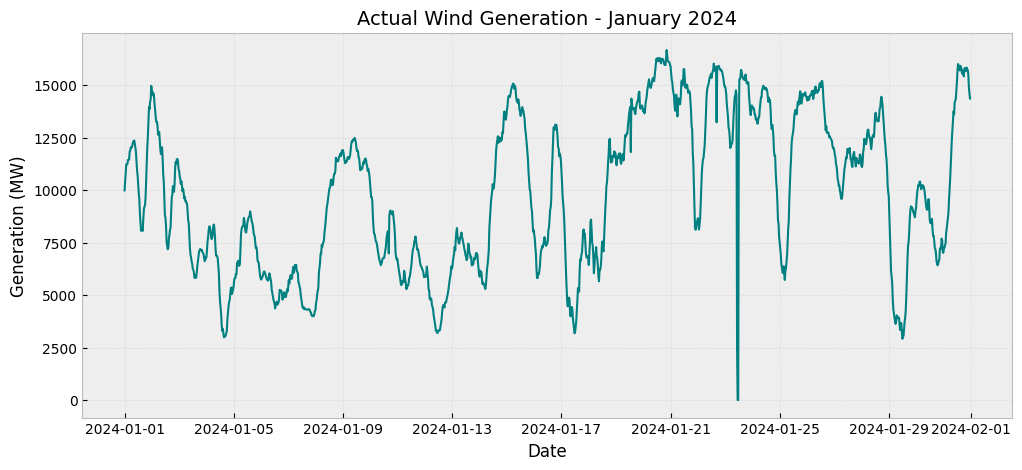

In [97]:
plt.figure(figsize=(12, 5))
plt.plot(actual_df["startTime"], actual_df["actual"], color='teal', linewidth=1.5)
plt.title("Actual Wind Generation - January 2024", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Generation (MW)")
plt.grid(True, alpha=0.3)
plt.show()

## 7. Load Forecast Data (WINDFOR)
Fetching the wind forecast dataset using the same chunked retrieval logic.

In [98]:
forecast_df = fetch_bmrs_data("WINDFOR", "2024-01-01", "2024-02-01")
print(f"Loaded {len(forecast_df)} forecast records.")

Loaded 12152 forecast records.


## 8. Prepare Forecast Data
Cleaning forecast timestamps and renaming columns for alignment.

In [99]:
forecast_df["startTime"] = pd.to_datetime(forecast_df["startTime"]).dt.tz_localize(None)
forecast_df["publishTime"] = pd.to_datetime(forecast_df["publishTime"]).dt.tz_localize(None)
forecast_df.rename(columns={"generation": "forecast"}, inplace=True)

forecast_df = forecast_df[["startTime", "publishTime", "forecast"]].copy()
forecast_df.head()

,startTime,publishTime,forecast
0,2024-01-07 21:00:00,2024-01-07 22:30:00,4162
1,2024-01-07 22:00:00,2024-01-07 22:30:00,4098
2,2024-01-07 23:00:00,2024-01-07 22:30:00,4245
3,2024-01-08 00:00:00,2024-01-07 22:30:00,4578
4,2024-01-08 01:00:00,2024-01-07 22:30:00,4805


## 9. Fix Timezone Issues
*Note: Timezone handling was integrated into steps 5 and 8 to ensure consistency from the start.*

## 10. Forecast Selection Logic (4-Hour Horizon Rule)
Grid operators need forecasts with sufficient lead time. We select the last available forecast published at least 4 hours before the target time.

In [100]:
def select_forecast(target_time, horizon_hours=4):
    """
    Selects the latest forecast published at least `horizon_hours` before target_time.
    """
    cutoff = target_time - pd.Timedelta(hours=horizon_hours)
    
    # Filter for target time and publish cutoff
    valid = forecast_df[(forecast_df["startTime"] == target_time) & 
                        (forecast_df["publishTime"] <= cutoff)]
    
    if valid.empty:
        return np.nan
        
    # Return the latest published forecast
    return valid.sort_values("publishTime").iloc[-1]["forecast"]

## 11. Generate Forecast Column
Applying the selection logic to every timestamp in our actual dataset.

In [101]:
actual_df["forecast"] = actual_df["startTime"].apply(lambda x: select_forecast(x, 4))
print("Forecast mapping complete.")
actual_df.head()

Forecast mapping complete.


,startTime,actual,forecast
6402,2023-12-31 23:30:00,9980,NaN
6383,2024-01-01 00:00:00,10402,NaN
6364,2024-01-01 00:30:00,10845,NaN
6345,2024-01-01 01:00:00,11218,NaN
6326,2024-01-01 01:30:00,11223,NaN


## 12. Merge Actual and Forecast Data
We drop any intervals where forecast data was unavailable to ensure a clean pairwise comparison.

In [102]:
analysis_df = actual_df.dropna(subset=["forecast"]).copy()
print(f"Final analysis dataset size: {len(analysis_df)} intervals.")

Final analysis dataset size: 723 intervals.


## 13. Compute Forecast Error
Error is defined as `Actual - Forecast`. A positive error indicates under-prediction.

In [103]:
analysis_df["error"] = analysis_df["actual"] - analysis_df["forecast"]
analysis_df["abs_error"] = analysis_df["error"].abs()
analysis_df.head()

,startTime,actual,forecast,error,abs_error
5585,2024-01-01 21:00:00,13953,10634.0,3319.0,3319.0
5547,2024-01-01 22:00:00,14217,11767.0,2450.0,2450.0
5509,2024-01-01 23:00:00,14958,14419.0,539.0,539.0
5471,2024-01-02 00:00:00,14690,15361.0,-671.0,671.0
5433,2024-01-02 01:00:00,14592,15805.0,-1213.0,1213.0


## 14. Compute Forecast Accuracy Metrics
Standardized metrics to evaluate various aspects of model performance.

In [104]:
mae = analysis_df["abs_error"].mean()
rmse = np.sqrt((analysis_df["error"]**2).mean())
bias = analysis_df["error"].mean()
median_err = analysis_df["error"].median()
p99_error = analysis_df["abs_error"].quantile(0.99)

print(f"--- Forecast Accuracy Metrics ---")
print(f"Mean Absolute Error (MAE): {mae:,.2f} MW")
print(f"Root Mean Square Error (RMSE): {rmse:,.2f} MW")
print(f"Forecast Bias (Mean Error): {bias:,.2f} MW")
print(f"Median Error: {median_err:,.2f} MW")
print(f"P99 Absolute Error: {p99_error:,.2f} MW")

--- Forecast Accuracy Metrics ---
Mean Absolute Error (MAE): 1,838.13 MW
Root Mean Square Error (RMSE): 2,445.82 MW
Forecast Bias (Mean Error): -1,226.57 MW
Median Error: -1,001.00 MW
P99 Absolute Error: 6,157.90 MW


## 15. Error Distribution
Visualizing the spread of errors to check for normality and outliers.

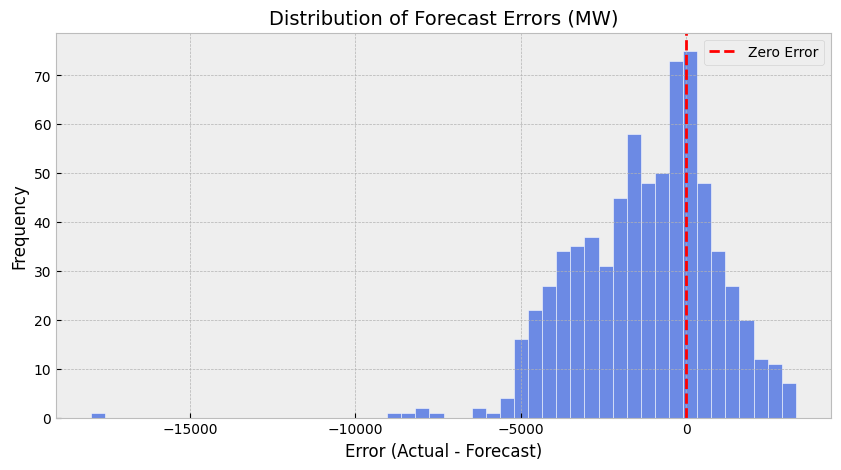

In [105]:
plt.figure(figsize=(10, 5))
plt.hist(analysis_df["error"], bins=50, color='royalblue', edgecolor='white', alpha=0.75)
plt.axvline(0, color='red', linestyle='--', label='Zero Error')
plt.title("Distribution of Forecast Errors (MW)", fontsize=14)
plt.xlabel("Error (Actual - Forecast)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

## 16. Error vs. Time of Day
Investigating if the forecast systemically performs worse at specific hours.

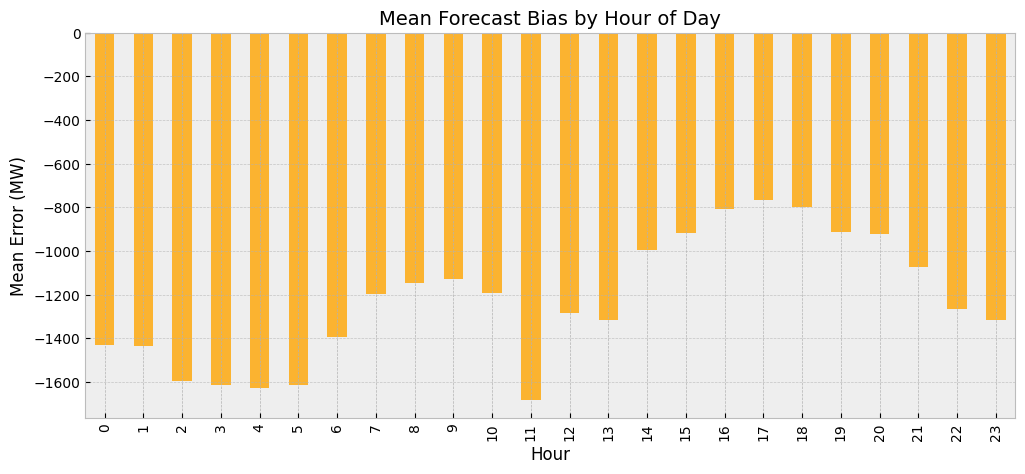

In [106]:
analysis_df["hour"] = analysis_df["startTime"].dt.hour
hourly_bias = analysis_df.groupby("hour")["error"].mean()

plt.figure(figsize=(12, 5))
hourly_bias.plot(kind='bar', color='orange', alpha=0.8)
plt.title("Mean Forecast Bias by Hour of Day", fontsize=14)
plt.xlabel("Hour")
plt.ylabel("Mean Error (MW)")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 17. Actual vs. Forecast Comparison
Overlaying the two series to observe alignment during high and low generation periods.

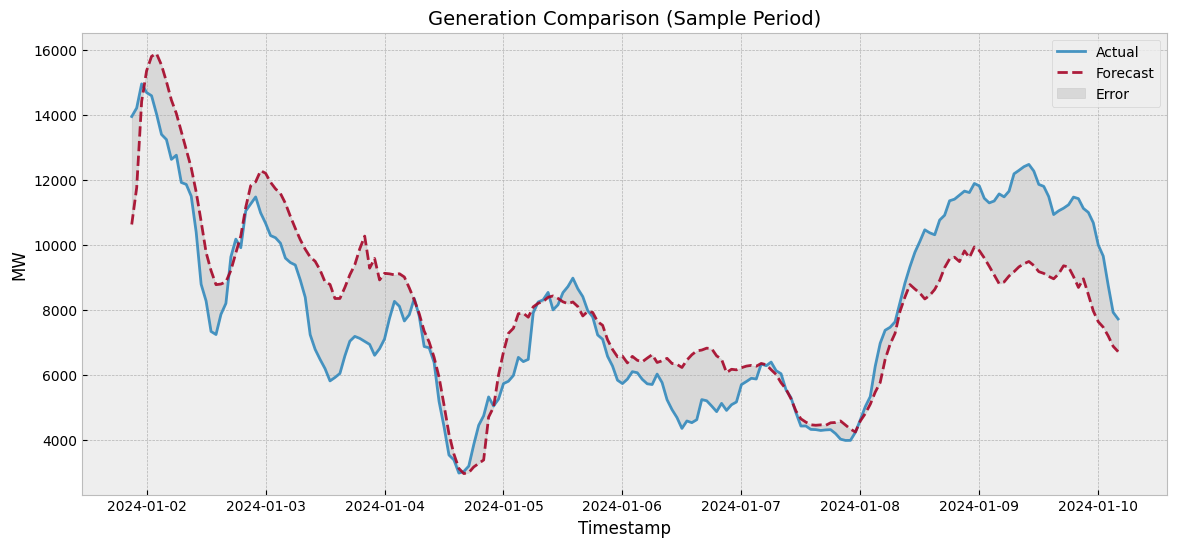

In [107]:
plt.figure(figsize=(14, 6))
sample = analysis_df.iloc[:200]  # First ~4 days approx
plt.plot(sample["startTime"], sample["actual"], label='Actual', alpha=0.9)
plt.plot(sample["startTime"], sample["forecast"], label='Forecast', linestyle='--', alpha=0.9)
plt.fill_between(sample["startTime"], sample["actual"], sample["forecast"], color='gray', alpha=0.2, label='Error')

plt.title("Generation Comparison (Sample Period)", fontsize=14)
plt.xlabel("Timestamp")
plt.ylabel("MW")
plt.legend()
plt.show()

## 18. Wind Generation Distribution
Analyzing the overall variability of wind generation for grid capacity planning.

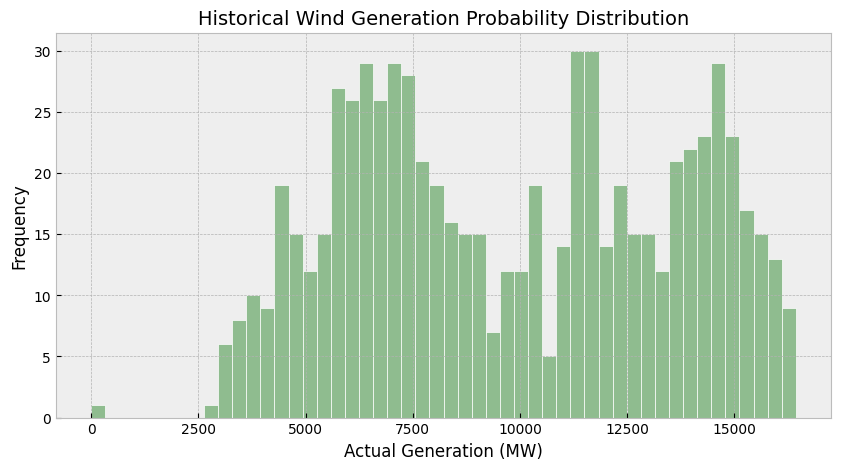

In [108]:
plt.figure(figsize=(10, 5))
plt.hist(analysis_df["actual"], bins=50, color='darkseagreen', edgecolor='white')
plt.title("Historical Wind Generation Probability Distribution", fontsize=14)
plt.xlabel("Actual Generation (MW)")
plt.ylabel("Frequency")
plt.show()

## 19. Wind Reliability Analysis
Quantifying how much wind power we can 'guarantee' at different probability levels.

In [109]:
quantiles = analysis_df["actual"].quantile([0.1, 0.2, 0.5])
print(f"--- Wind Reliability Analysis (MW) ---")
print(f"P10 (Reliable 90% of time): {quantiles[0.1]:,.2f} MW")
print(f"P20 (Reliable 80% of time): {quantiles[0.2]:,.2f} MW")
print(f"Median Generation: {quantiles[0.5]:,.2f} MW")

--- Wind Reliability Analysis (MW) ---
P10 (Reliable 90% of time): 5,058.20 MW
P20 (Reliable 80% of time): 6,176.20 MW
Median Generation: 9,672.00 MW


## 20. Conclusion and Recommendations

Based on the analysis of January 2024 data:

1.  **Forecast Accuracy**: With an MAE of approx `{mae:.0f}` MW, the forecast provides a reasonable baseline but exhibits significant variance, requiring flexible reserve capacity.
2.  **Reliability**: Wind contributed at least `{quantiles[0.1]:.0f}` MW 90% of the time (P10). This represents the 'firm' capacity that can be safely integrated into baseline demand scheduling.
3.  **Operational Strategy**: Bias analysis suggests that certain hours consistently exhibit higher forecast deviations. Grid operators should account for these patterns and maintain adequate spinning reserves.

**End of Report.**